In [1]:
"""
Étapes 1 et 2 — Audit des données & Analyse statistique exploratoire (EDA)
Objectif : vérifier la fiabilité du dataset avant toute modélisation, puis
comprendre statistiquement les variables et leur lien avec la cible, pour
justifier les décisions prises dans feature_engineering.py.
"""
import pandas as pd
import numpy as np

# -----------------------------------------------------------------
# 1. Chargement des données brutes
# -----------------------------------------------------------------
df = pd.read_csv("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\ai4i2020.csv")

# ===================================================================
# ÉTAPE 1 — AUDIT STRUCTUREL
# But : détecter tout problème de qualité de données AVANT de modéliser.
# ===================================================================
print("=" * 60)
print("1. AUDIT STRUCTUREL")
print("=" * 60)
print("Dimensions :", df.shape)

print("\nTypes de données :")
print(df.dtypes)

# isna().sum() compte les valeurs manquantes par colonne. Un modèle ne peut
# pas s'entraîner sur des valeurs manquantes non traitées.
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())

# duplicated() détecte les lignes strictement identiques. Des doublons
# fausseraient l'apprentissage en sur-représentant certains cas.
print("\nDoublons (lignes complètes) :", df.duplicated().sum())
print("Doublons Product ID :", df["Product ID"].duplicated().sum())

# Vérifie que UDI est bien un identifiant séquentiel propre (1 à 10000),
# confirme l'intégrité du fichier (pas de lignes manquantes/corrompues).
udi_ok = (df["UDI"] == range(1, len(df) + 1)).all()
print("UDI unique et séquentiel de 1 à 10000 ?", udi_ok)

# ===================================================================
# ÉTAPE 2 — STATISTIQUES DESCRIPTIVES
# But : comprendre la forme de chaque distribution avant de décider
# des transformations à appliquer (feature engineering).
# ===================================================================
print("\n" + "=" * 60)
print("2. STATISTIQUES DESCRIPTIVES (variables numériques)")
print("=" * 60)
num_cols = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
]
desc = df[num_cols].describe().T
# skewness : mesure l'asymétrie de la distribution (0 = symétrique comme une
# loi normale, >0 = étalée à droite, <0 = étalée à gauche).
desc["skewness"] = df[num_cols].skew()
# kurtosis : mesure le poids des valeurs extrêmes (queues de distribution).
# Une valeur élevée signale des valeurs extrêmes plus fréquentes qu'une loi normale.
desc["kurtosis"] = df[num_cols].kurt()
print(desc)

# ===================================================================
# ÉTAPE 2 (suite) — DÉTECTION D'OUTLIERS PAR LA MÉTHODE IQR
# But : repérer les valeurs extrêmes, PUIS vérifier si elles sont du bruit
# ou un signal prédictif avant de décider de les garder/traiter.
# ===================================================================
print("\n" + "=" * 60)
print("3. DÉTECTION D'OUTLIERS (méthode IQR)")
print("=" * 60)
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:30s}: {n_outliers:4d} outliers ({100*n_outliers/len(df):.2f}%)  "
          f"[bornes: {lower:.1f} - {upper:.1f}]")

# Vérification cruciale : ces outliers sont-ils informatifs (liés à la panne)
# ou de simples erreurs de mesure ? On compare le taux de panne DANS et HORS
# outliers pour chaque variable clé.
print("\n" + "=" * 60)
print("4. LES OUTLIERS SONT-ILS INFORMATIFS OU DU BRUIT ?")
print("=" * 60)
taux_global = df["Machine failure"].mean()
print(f"Taux de panne global (référence) : {100*taux_global:.2f}%\n")
for col in ["Rotational speed [rpm]", "Torque [Nm]"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask_out = (df[col] < lower) | (df[col] > upper)
    taux_out = df.loc[mask_out, "Machine failure"].mean()
    taux_in = df.loc[~mask_out, "Machine failure"].mean()
    ratio = taux_out / taux_global
    print(f"{col}:")
    print(f"  Taux de panne DANS les outliers : {100*taux_out:.2f}%")
    print(f"  Taux de panne HORS outliers     : {100*taux_in:.2f}%")
    print(f"  => Risque de panne x{ratio:.1f} par rapport à la moyenne\n")
# Conclusion (justifie la décision prise dans feature_engineering.py) :
# les outliers sont fortement informatifs (risque x26 sur Torque) -> on ne
# les supprime PAS, contrairement à une pratique de nettoyage "par défaut".

# ===================================================================
# ÉTAPE 2 (suite) — MATRICE DE CORRÉLATION
# But : détecter la multicolinéarité (variables redondantes) et identifier
# les variables les plus liées à la cible.
# ===================================================================
print("=" * 60)
print("5. MATRICE DE CORRÉLATION (variables numériques + cible)")
print("=" * 60)
corr_matrix = df[num_cols + ["Machine failure"]].corr()
print(corr_matrix.round(3))
# Constat clé : Air/Process temperature corrélées à 0.88, et Rotational speed/
# Torque corrélées à -0.88 -> justifie la création de temp_diff et power_W
# dans feature_engineering.py (capturer l'écart utile plutôt que la redondance).

# ===================================================================
# ÉTAPE 2 (suite) — ANALYSE PAR SOUS-TYPE DE PANNE
# But : comprendre la composition de la cible Machine failure, et repérer
# le risque de data leakage si ces colonnes étaient utilisées comme features.
# ===================================================================
print("\n" + "=" * 60)
print("6. ANALYSE PAR SOUS-TYPE DE PANNE")
print("=" * 60)
for col in ["TWF", "HDF", "PWF", "OSF", "RNF"]:
    n = df[col].sum()
    print(f"{col}: {n} occurrences ({100*n/len(df):.2f}%)")
print(f"\nSomme des sous-pannes : {df[['TWF','HDF','PWF','OSF','RNF']].sum().sum()}")
print(f"Machine failure total : {df['Machine failure'].sum()}")
overlap = df[(df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1) > 1)]
print(f"Lignes avec plusieurs causes de panne simultanées : {len(overlap)}")

# ===================================================================
# ÉTAPE 2 (suite) — RÉPARTITION PAR TYPE DE PRODUIT
# But : vérifier si la qualité du produit (L/M/H) influence le taux de panne,
# pour justifier l'encodage ordinal choisi dans feature_engineering.py.
# ===================================================================
print("\n" + "=" * 60)
print("7. RÉPARTITION PAR TYPE DE PRODUIT")
print("=" * 60)
print(df["Type"].value_counts())
print("\nTaux de panne par Type :")
print(df.groupby("Type")["Machine failure"].mean().sort_values(ascending=False))


1. AUDIT STRUCTUREL
Dimensions : (10000, 14)

Types de données :
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Valeurs manquantes par colonne :
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                 

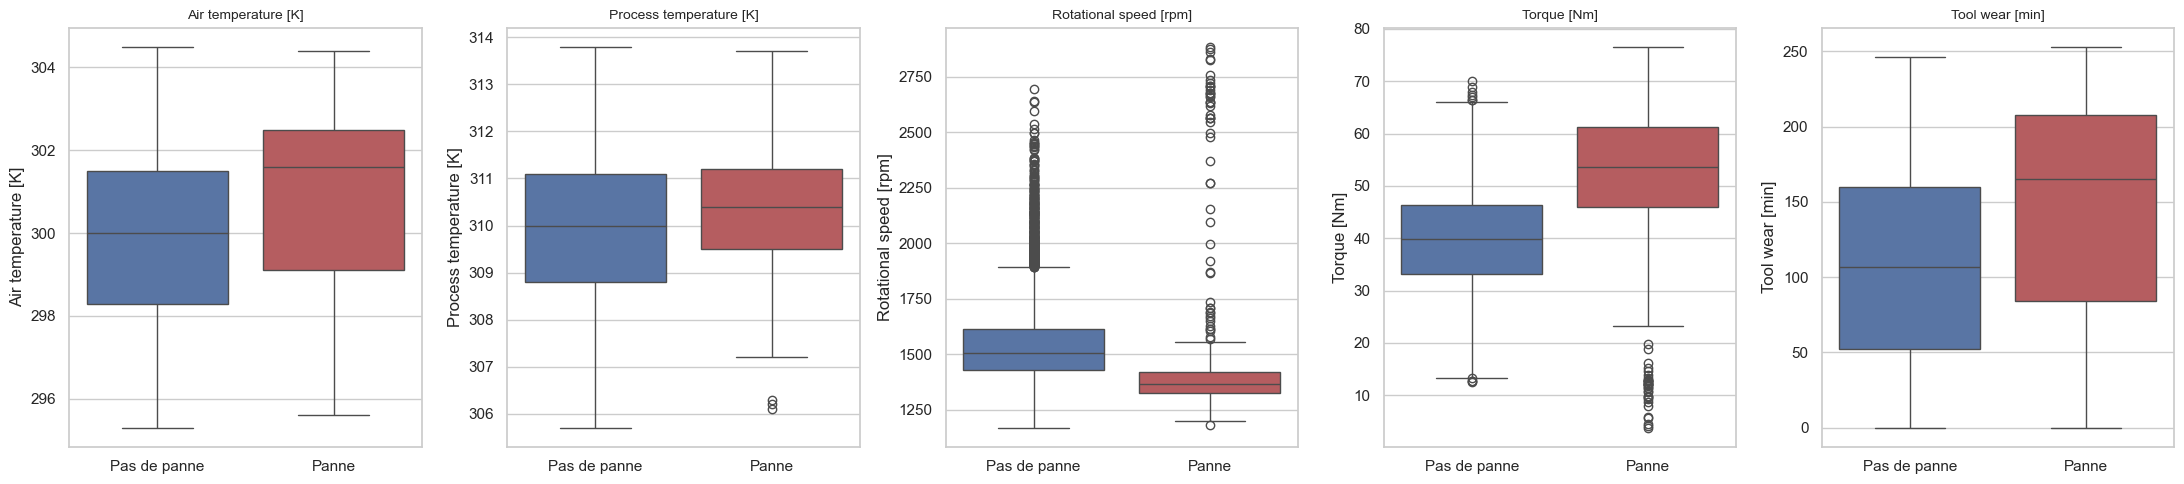

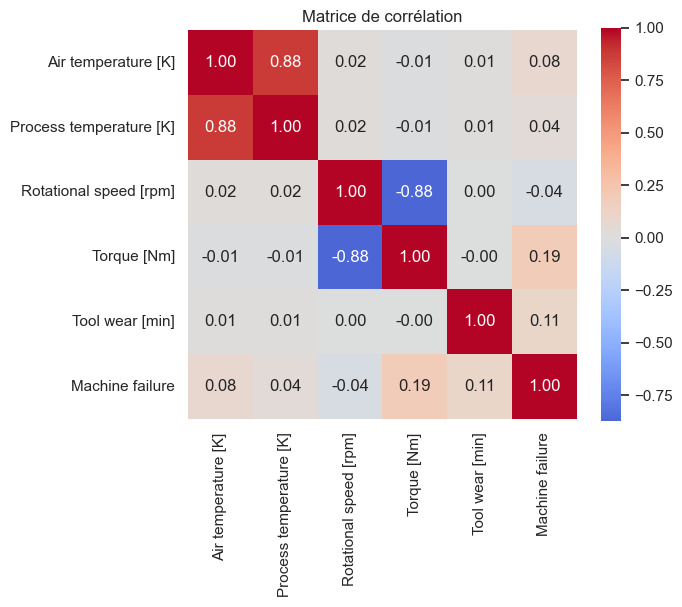

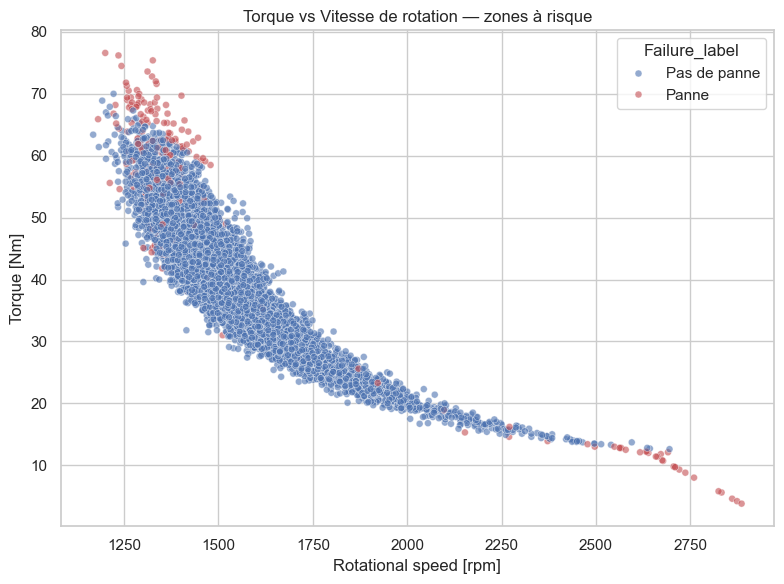

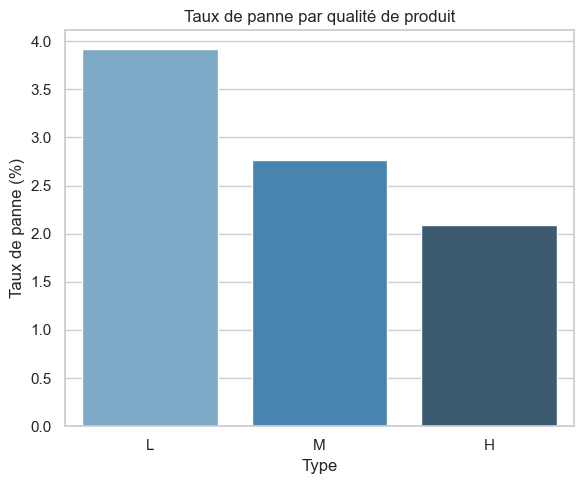

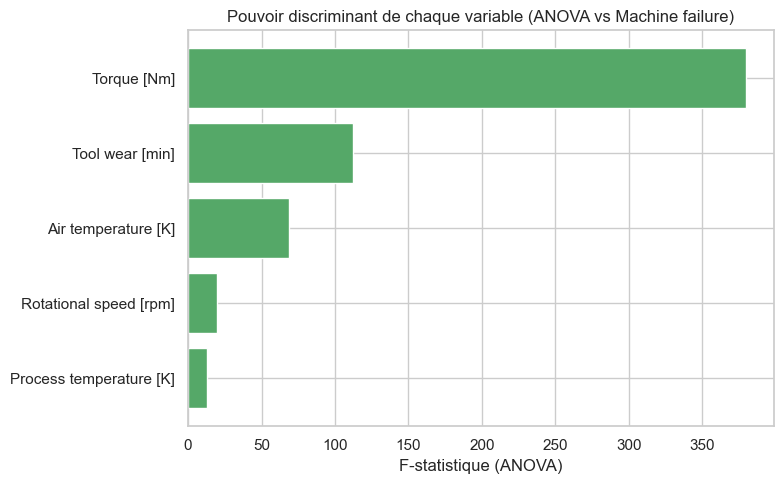

In [2]:
"""
Étape 2 (suite) — Visualisation EDA
Objectif : confirmer visuellement les décisions prises lors de l'audit statistique
(distribution des variables par classe, corrélations, effet des outliers).
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# Chargement
df1 = pd.read_csv("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\ai4i2020.csv")
df=df1.copy()
df["Failure_label"] = df["Machine failure"].map({0: "Pas de panne", 1: "Panne"})

num_cols = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
]

sns.set_theme(style="whitegrid")

# 1. Distributions par classe (boxplots) — vérifie si les distributions
#    diffèrent visiblement entre panne / pas panne
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Failure_label", y=col, ax=ax, hue="Failure_label",
                palette={"Pas de panne": "#4C72B0", "Panne": "#C44E52"}, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\eda_boxplots_par_classe.png", dpi=120)
#plt.close()

# 2. Matrice de corrélation (heatmap)
plt.figure(figsize=(7, 6))
corr = df[num_cols + ["Machine failure"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\eda_correlation_heatmap.png", dpi=120)
#plt.close()

# 3. Torque vs Rotational speed, colorié par panne — visualise directement
#    la zone à haut risque identifiée dans l'analyse des outliers
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="Rotational speed [rpm]", y="Torque [Nm]",
    hue="Failure_label", palette={"Pas de panne": "#4C72B0", "Panne": "#C44E52"},
    alpha=0.6, s=25
)
plt.title("Torque vs Vitesse de rotation — zones à risque")
plt.tight_layout()
plt.savefig("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\eda_scatter_torque_speed.png", dpi=120)
#plt.close()

# 4. Taux de panne par type de produit
plt.figure(figsize=(6, 5))
taux = df.groupby("Type")["Machine failure"].mean().sort_values(ascending=False) * 100
sns.barplot(x=taux.index, y=taux.values, hue=taux.index, palette="Blues_d", legend=False)
plt.ylabel("Taux de panne (%)")
plt.title("Taux de panne par qualité de produit")
plt.tight_layout()
plt.savefig("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\eda_taux_panne_par_type.png", dpi=120)
#plt.close()

# 5. ANOVA — visualisation du pouvoir discriminant de chaque variable
#    Barres = F-statistique (plus haut = variable qui sépare mieux panne/pas panne).

anova_results = []
for col in num_cols:
    groupe_ok = df.loc[df["Machine failure"] == 0, col]
    groupe_panne = df.loc[df["Machine failure"] == 1, col]
    f_stat, p_value = stats.f_oneway(groupe_ok, groupe_panne)
    anova_results.append({"variable": col, "F_statistique": f_stat})
anova_df = pd.DataFrame(anova_results).sort_values("F_statistique", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(anova_df["variable"], anova_df["F_statistique"], color="#55A868")
plt.xlabel("F-statistique (ANOVA)")
plt.title("Pouvoir discriminant de chaque variable (ANOVA vs Machine failure)")
plt.tight_layout()
plt.savefig("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\eda_anova_fstat.png", dpi=120)
#plt.close()



In [3]:
#Future engineering
# 1. Chargement des données brutes
import pandas as pd
import numpy as np
df1 = pd.read_csv("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\ai4i2020.csv")
df=df1.copy()
# 2. Encodage ordinal de la variable catégorielle "Type"
type_map={"L":0,"M":1,"H":2}
df["Type_encoded"]=df["Type"].map(type_map)
# 3. Création des variables dérivées (feature engineering "métier")
#temp_diff : écart entre température procédé et température ambiante.
df["temp_diff"]=df["Process temperature [K]"]-df["Air temperature [K]"]
#power_W : puissance mécanique en Watts = Couple [Nm] x Vitesse angulaire [rad/s].
df["power_W"]=df["Torque [Nm]"]*df["Rotational speed [rpm]"]*(np.pi/30)
df["strain"]=df["Torque [Nm]"]*df["Tool wear [min]"]

#Definition des colonnes finales du modèle
feature_cols = [
    "Type_encoded",
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
    "temp_diff", "power_W", "strain"]
target_col="Machine failure"

#sauvegarde du dataset enrichi 
df.to_csv("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\ai4i2020_featured.csv", index=False)

Train : 8000 lignes (3.39% de pannes)
Test  : 2000 lignes (3.40% de pannes)

--- Regression logistique ---
Recall=0.882 | Precision=0.178 | F1=0.296 | AUC=0.939

--- Evaluation de la Regression logistique ---
               precision    recall  f1-score   support

Pas de panne       1.00      0.86      0.92      1932
       Panne       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000



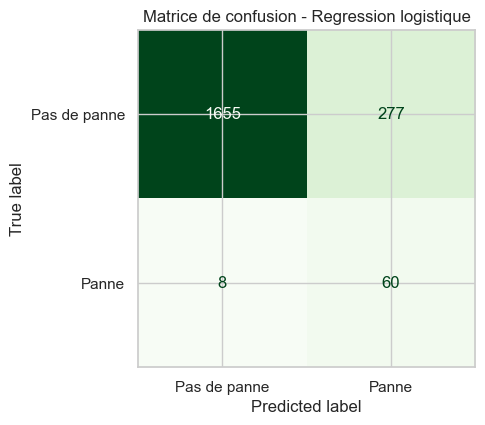


--- Random Forest ---
Recall=0.779 | Precision=0.964 | F1=0.862 | AUC=0.985

--- Evaluation du Random Forest ---
               precision    recall  f1-score   support

Pas de panne       0.99      1.00      1.00      1932
       Panne       0.96      0.78      0.86        68

    accuracy                           0.99      2000
   macro avg       0.98      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000



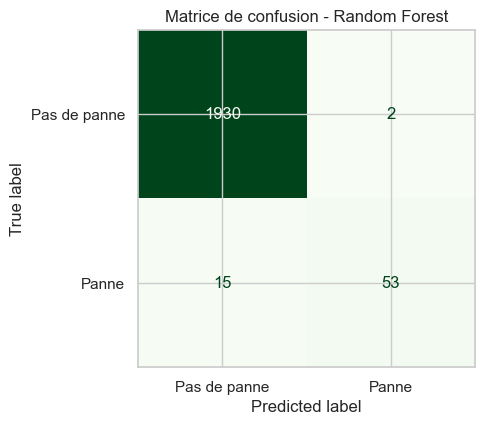


--- Random Forest ---
Recall=0.779 | Precision=0.964 | F1=0.862 | AUC=0.501

--- Evaluation du RandomForest + Smote ---
               precision    recall  f1-score   support

Pas de panne       0.99      0.97      0.98      1932
       Panne       0.49      0.85      0.62        68

    accuracy                           0.96      2000
   macro avg       0.74      0.91      0.80      2000
weighted avg       0.98      0.96      0.97      2000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


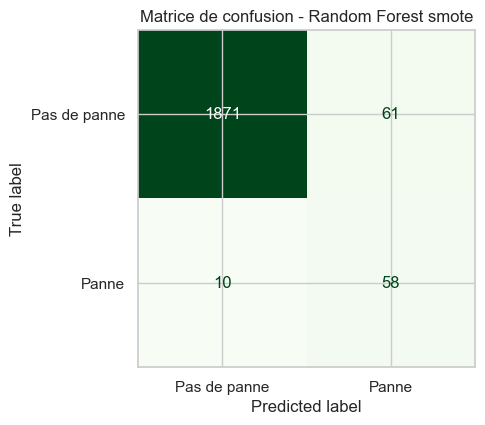

['E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\models\\model_rf_smote.joblib']

In [16]:
#split Train/Test et entrainement des modèles 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    f1_score, recall_score, precision_score, roc_auc_score,
    ConfusionMatrixDisplay, confusion_matrix, precision_recall_curve, classification_report
)
from imblearn.over_sampling import SMOTE

df=pd.read_csv("E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\ai4i2020_featured.csv")
feature_cols = [
    "Type_encoded",
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
    "temp_diff", "power_W", "strain"]
target_col="Machine failure"



X=df[feature_cols]
y=df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,train_size=8000, test_size=2000, stratify=y, random_state=42
)
print(f"Train : {X_train.shape[0]} lignes ({100*y_train.mean():.2f}% de pannes)")
print(f"Test  : {X_test.shape[0]} lignes ({100*y_test.mean():.2f}% de pannes)")

#Mise à l'echelle des données pour la regression logistique 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Modèle de regression logistique

model_reglog = LogisticRegression(
    class_weight="balanced", random_state=42, max_iter=1000
)
model_reglog.fit(X_train_scaled, y_train)
pred_reglog = model_reglog.predict(X_test_scaled)
 
r_reglog = recall_score(y_test, pred_reglog)
p_reglog = precision_score(y_test, pred_reglog)
f_reglog = f1_score(y_test, pred_reglog)
auc_reglog = roc_auc_score(y_test, model_reglog.predict_proba(X_test_scaled)[:, 1])
 
print("\n--- Regression logistique ---")
print(f"Recall={r_reglog:.3f} | Precision={p_reglog:.3f} | "
      f"F1={f_reglog:.3f} | AUC={auc_reglog:.3f}")
print("\n--- Evaluation de la Regression logistique ---\n",classification_report(y_test, pred_reglog, target_names=["Pas de panne", "Panne"]))

matrice = confusion_matrix(y_test, pred_reglog)
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
ConfusionMatrixDisplay(
    matrice, display_labels=["Pas de panne", "Panne"]
).plot(ax=axes, cmap="Greens", colorbar=False)
axes.set_title("Matrice de confusion - Regression logistique")
plt.tight_layout()
plt.show()
#print(matrice)
#modèle RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1)

model_rf.fit(X_train, y_train)  
pred_rf = model_rf.predict(X_test)
 
r_rf = recall_score(y_test, pred_rf)
p_rf = precision_score(y_test, pred_rf)
f_rf = f1_score(y_test, pred_rf)

auc_rf = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:, 1])
 
print("\n--- Random Forest ---")
print(f"Recall={r_rf:.3f} | Precision={p_rf:.3f} | "
      f"F1={f_rf:.3f} | AUC={auc_rf:.3f}")
print("\n--- Evaluation du Random Forest ---\n",classification_report(y_test, pred_rf, target_names=["Pas de panne", "Panne"]))

matrice = confusion_matrix(y_test, pred_rf)
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
ConfusionMatrixDisplay(
    matrice, display_labels=["Pas de panne", "Panne"]
).plot(ax=axes, cmap="Greens", colorbar=False)
axes.set_title("Matrice de confusion - Random Forest")
plt.tight_layout()
#plt.savefig(MODEL_DIR + "confusion_matrix_rf.png")
plt.show()
#print(matrice)
 
#Modèle RandomForest + Smote
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


model_rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
)
model_rf_smote.fit(X_train_smote, y_train_smote)
pred_rf_smote = model_rf_smote.predict(X_test_scaled)

r_rfsmote = recall_score(y_test, pred_rf)
p_rfsmote = precision_score(y_test, pred_rf)
f_rfsmote = f1_score(y_test, pred_rf)

auc_rfsmote = roc_auc_score(y_test, model_rf_smote.predict_proba(X_test)[:, 1])
 
print("\n--- Random Forest ---")
print(f"Recall={r_rfsmote:.3f} | Precision={p_rfsmote:.3f} | "
      f"F1={f_rfsmote:.3f} | AUC={auc_rfsmote:.3f}")
print("\n--- Evaluation du RandomForest + Smote ---\n",classification_report(y_test, pred_rf_smote, target_names=["Pas de panne", "Panne"]))
matrice = confusion_matrix(y_test, pred_rf_smote)
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
ConfusionMatrixDisplay(
    matrice, display_labels=["Pas de panne", "Panne"]
).plot(ax=axes, cmap="Greens", colorbar=False)
axes.set_title("Matrice de confusion - Random Forest smote")
plt.tight_layout()
plt.show()
#print(matrice)
joblib.dump(model_reglog, "E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\models\\model_reglog.joblib")
joblib.dump(model_rf, "E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\models\\model_rf.joblib")
joblib.dump(model_rf_smote, "E:\\AKWPJ\\EEEIA_2026\\Projet_Agent_IA\\models\\model_rf_smote.joblib")